- 캐글 설치

In [12]:
!pip install kaggle

- 캐글에서 titanic 데이터셋 다운로드 및 압축해제
- train.csv 로딩 후 데이터 크기 확인

In [13]:
!kaggle --version

Kaggle CLI 2.0.0


In [3]:
import os
print(os.path.expanduser('~'))

C:\Users\User


In [22]:
import os
import pandas as pd
import kaggle
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 캐글 API를 사용하여 타이타닉 데이터셋 다운로드 (경연 대회 데이터)
# 터미널 명령어인 '!kaggle competitions download -c titanic' 과 동일한 역할 수행
# os.system('kaggle competitions download -c titanic')
kaggle.api.competition_download_files('titanic', path='.')

# 다운로드된 압축 파일 해제 (운영체제에 따라 zipfile 라이브러리 사용 권장)
import zipfile
with zipfile.ZipFile('titanic.zip','r') as zip_ref:
    zip_ref.extractall('.')

# CSV 파일 읽기
df = pd.read_csv('train.csv')

# 데이터 확인
print(df.shape)
print(df.head(3))

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- 결측치 확인 및 대체

In [58]:
# 결측치 확인
print(df.isnull().sum())

# 1. Age(나이) 결측치: 데이터의 중앙값(median)으로 대체
df.Age.median()
df['Age'] = df['Age'].fillna(df.Age.median())
# 같은 결과 나옴 df.Age = df.Age.fillna(df.Age.median())

df.Age.isnull().sum()
# 2. Embarked(탑승 항구) 결측치: 최빈값(mode)으로 대체 (결측치가 2개뿐이므로)
df.Embarked.mode()
df['Embarked'] = df['Embarked'].fillna(df.Embarked.mode()[0])
df['Embarked'].isnull().sum()
# 3. Cabin(객실 번호) 결측치: 결측치가 너무 많아(600개 이상) 열 자체를 삭제하거나, 
# 결측치 자체를 의미 있는 'Unknown'이라는 범주로 대체할 수 있습니다.
# 여기서는 'U' (Unknown)로 대체합니다.
df['Cabin'] = df['Cabin'].fillna('U')
df.Cabin.isnull()


PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Cabin          0
Embarked       0
Log_Fare       0
Age_Group      0
FamilySize     0
IsAlone        0
Sex_mapped     0
Age_scaled     0
Fare_scaled    0
dtype: int64


0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Cabin, Length: 891, dtype: bool

- 성별(sex)과 탑승 항구(Embarked) 컬럼 인코딩

In [61]:
# 1. Sex(성별): 'male', 'female' 두 가지이므로 0과 1로 매핑 (Label Encoding과 유사)
sex_mapping = {'male': 0 , 'female' : 1}
df['Sex_mapped'] = df['Sex'].map(sex_mapping)
df['Sex_mapped'].head()
# df.Sex = df.Sex.map({'male':0, 'female':1})

# 2. Embarked(탑승 항구): 'C', 'Q', 'S' 세 가지이며 순서가 없으므로 원-핫 인코딩
# pd.get_dummies를 사용하고 기존 컬럼은 삭제, 다중공선성 방지를 위해 drop_first=True 적용
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df.columns



Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Cabin', 'Log_Fare', 'Age_Group', 'FamilySize', 'IsAlone',
       'Sex_mapped', 'Age_scaled', 'Fare_scaled', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

- 지금까지 작업한 내용 확인

In [17]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_mapped
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,0


- 나이(Age)와 요금(Fare)는 표준화 작업( 컬럼명 : 'Age_scaled', 'Fare_scaled' )

In [40]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# StandardScaler를 사용하여 평균 0, 표준편차 1로 맞춤
std_scaler = StandardScaler()
df['Age_scaled'] = std_scaler.fit_transform(df[['Age']])
df['Age_scaled'].isnull().sum()

df['Fare_scaled'] = std_scaler.fit_transform(df[['Fare']])

# df[['Age_scaled','Fare_scaled']] = std_scaler.fit_transform(df[['Age','Fare_scaled']])
# 2차원 배열 형태로 입력해야 하므로 [['Age', 'Fare']] 형태로 묶어줌

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Log_Fare,Age_Group,FamilySize,IsAlone,Sex_mapped,Age_scaled,Fare_scaled
0,1,0,3,male,22.0,1,0,7.2500,U,S,2.110213,Young Adult,2,0,0,-0.565736,-0.502445
1,2,1,1,female,38.0,1,0,71.2833,C85,C,4.280593,Adult,2,0,1,0.663861,0.786845
2,3,1,3,female,26.0,0,0,7.9250,U,S,2.188856,Young Adult,1,1,1,-0.258337,-0.488854
3,4,1,1,female,35.0,1,0,53.1000,C123,S,3.990834,Young Adult,2,0,1,0.433312,0.420730
4,5,0,3,male,35.0,0,0,8.0500,U,S,2.202765,Young Adult,1,1,0,0.433312,-0.486337


- 요금은 로그변환, 나이는 5개의 범주형 그룹으로 구간화
- 0, 12, 18, 35, 60, 100
- 'Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'

In [41]:

# 1. 데이터 변환: 요금(Fare) 데이터의 비대칭성을 줄이기 위해 로그 변환 적용
# 요금이 0인 경우가 있으므로 np.log1p (log(1+x)) 사용
df['Log_Fare'] = np.log1p(df.Fare)

# 2. 구간화(Binning): 나이(Age)를 5개의 범주형 그룹으로 나눔
bins = [0,12,18,35,60,100]
labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
df['Age_Group'] = pd.cut(df.Age, bins=bins, labels=labels)



In [25]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Log_Fare,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2.110213,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,4.280593,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2.188856,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3.990834,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,2.202765,Young Adult


- 파생변수(FamilySize : 가족수) 생성
- 가족 수 = 형제/배우자 수 + 부모/자녀 수 + 1(본인)
- 가족 규모에 따라 혼자 탑승했는지(IsAlone) 여부를 나타내는 파생 변수 추가 생성
- 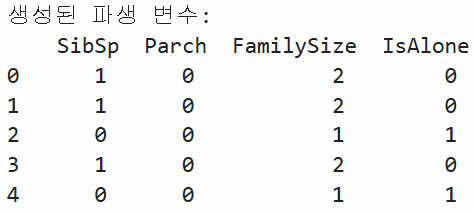

In [42]:
# 가족 수 = 형제/배우자 수 + 부모/자녀 수 + 1(본인)
df['FamilySize'] = df.SibSp + df.Parch + 1 

# 가족 규모에 따라 혼자 탑승했는지(IsAlone) 여부를 나타내는 파생 변수 추가 생성
df['IsAlone'] = (df['FamilySize']==1).map({True:1, False:0})



- 작업결과 출력

In [43]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Log_Fare,Age_Group,FamilySize,IsAlone,Sex_mapped,Age_scaled,Fare_scaled
0,1,0,3,male,22.0,1,0,7.2500,U,S,2.110213,Young Adult,2,0,0,-0.565736,-0.502445
1,2,1,1,female,38.0,1,0,71.2833,C85,C,4.280593,Adult,2,0,1,0.663861,0.786845
2,3,1,3,female,26.0,0,0,7.9250,U,S,2.188856,Young Adult,1,1,1,-0.258337,-0.488854
3,4,1,1,female,35.0,1,0,53.1000,C123,S,3.990834,Young Adult,2,0,1,0.433312,0.420730
4,5,0,3,male,35.0,0,0,8.0500,U,S,2.202765,Young Adult,1,1,0,0.433312,-0.486337


- 불필요한 컬럼 삭제( 'Ticket', 'Name' )

In [34]:
df = df.drop(['Ticket','Name'], axis=1)

In [37]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Log_Fare,Age_Group,FamilySize,IsAlone
0,1,0,3,male,22.0,1,0,7.2500,U,S,2.110213,Young Adult,2,0
1,2,1,1,female,38.0,1,0,71.2833,C85,C,4.280593,Adult,2,0
2,3,1,3,female,26.0,0,0,7.9250,U,S,2.188856,Young Adult,1,1
3,4,1,1,female,35.0,1,0,53.1000,C123,S,3.990834,Young Adult,2,0
4,5,0,3,male,35.0,0,0,8.0500,U,S,2.202765,Young Adult,1,1


In [64]:
df.shape

(891, 18)

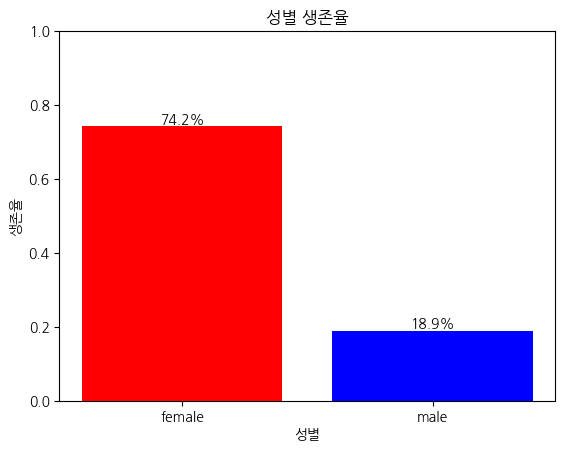

In [65]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import matplotlib.ticker as mtick

survived_by_sex = df.groupby(df.Sex)['Survived'].mean()
bars = plt.bar(survived_by_sex.index, survived_by_sex, color=['red','blue'])
plt.bar_label(bars, labels= survived_by_sex.map(lambda v : f"{v*100:.1f}%"))
plt.ylim(0,1)
plt.xlabel('성별')
plt.ylabel('생존율')
plt.title('성별 생존율')
plt.show()

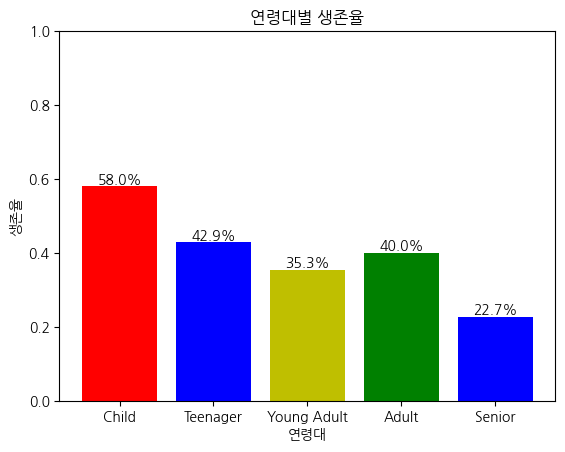

In [67]:
survived_by_age_g = df.groupby(df.Age_Group, observed=False)['Survived'].mean()
bars1 = plt.bar(survived_by_age_g.index, survived_by_age_g, color=['red','blue','y','g','b'])
plt.bar_label(bars1, labels= survived_by_age_g.map(lambda v : f"{v*100:.1f}%"))
plt.ylim(0,1)
plt.xlabel('연령대')
plt.ylabel('생존율')
plt.title('연령대별 생존율')
plt.show()